In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import joblib
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Load and preprocess the data

df = pd.read_excel(r'updated_fc_predictions_with_fc_hat_all_data.xlsx', sheet_name='7all')
df.dropna(inplace=True)

features = ['PC', 'PC_TYPE','FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a','SCM%', 'CAGG%', 'FAGG%', 'FA%','SS%','SF%']

X = df[features].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)


# Define the ANN model
class ANNModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(ANNModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


# Set ANN hyperparameters
layers = 2  # Number of layers
neurons = 52  # Number of neurons per layer
learning_rate = 0.00077  # Learning rate

# Create the ANN model
ann_model = ANNModel(input_dim=Xtrain.shape[1], layers=layers, neurons=neurons)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ann_model.to(device)
optimizer = optim.Adam(ann_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Training the model
epochs = 300
for epoch in range(epochs):
    ann_model.train()
    optimizer.zero_grad()
    ytrain_tensor = torch.FloatTensor(ytrain).view(-1, 1)  # Ensure ytrain is a column vector
    ytrain_pred = ann_model(torch.FloatTensor(Xtrain))
    loss = criterion(ytrain_pred, ytrain_tensor)
    loss.backward()
    optimizer.step()

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('w/b')].min(), X_normal[:, features.index('w/b')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['w/b'] = fa_percent_range  # Vary FA%

# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values)

# Make predictions using the ANN model
pdp_predictions_normalized = ann_model(pdp_data_tensor).detach().numpy().flatten()  # Ensure predictions are 1D

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['w/b'] * x_std[features.index('w/b')] + x_mean[features.index('w/b')]

# Ensure fa_percent_original is a 1D array
fa_percent_original = fa_percent_original.values.flatten()  # Flatten to ensure 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({
    'w/b': fa_percent_original, 
    'Predicted_fc': pdp_predictions_original
})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_ANN_wb_7.csv', index=False)

# torch.save(ann_model, "KInn_model_7.pth")

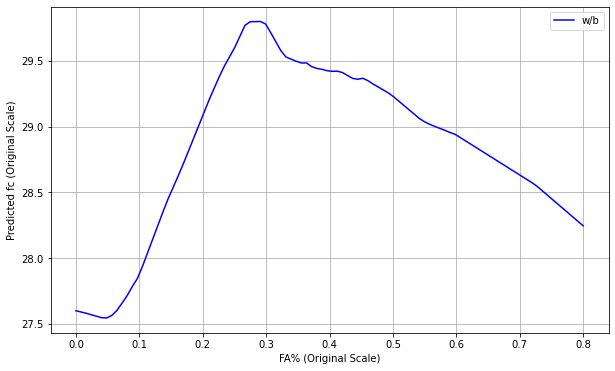

In [53]:
# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
wb_ratio_range = np.linspace(X_normal[:, features.index('SCM%')].min(), X_normal[:, features.index('SCM%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (wb_ratio_range.size, 1)), columns=features)
pdp_data['SCM%'] = wb_ratio_range  # Vary FA%

pdp_data['w/b']=0.45
pdp_data['w/b'] = (pdp_data['w/b']-x_mean[-8])/x_std[-8]
# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
pdp_predictions_normalized = ann_model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['SCM%'] * x_std[features.index('SCM%')] + x_mean[features.index('SCM%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D
# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'SCM%': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_KINN_7_SCM%_0.45.csv', index=False)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='w/b', color='blue')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()

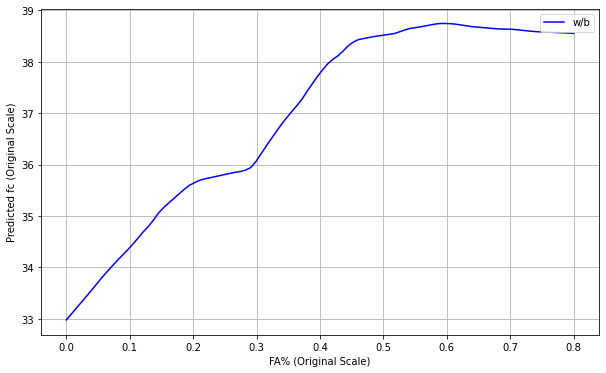

In [54]:
# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
wb_ratio_range = np.linspace(X_normal[:, features.index('SCM%')].min(), X_normal[:, features.index('SCM%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (wb_ratio_range.size, 1)), columns=features)
pdp_data['SCM%'] = wb_ratio_range  # Vary FA%

pdp_data['w/b']=0.35
pdp_data['w/b'] = (pdp_data['w/b']-x_mean[-8])/x_std[-8]
# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
pdp_predictions_normalized = ann_model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['SCM%'] * x_std[features.index('SCM%')] + x_mean[features.index('SCM%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D
# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'SCM%': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_KINN_7_SCM%_0.35.csv', index=False)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='w/b', color='blue')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()

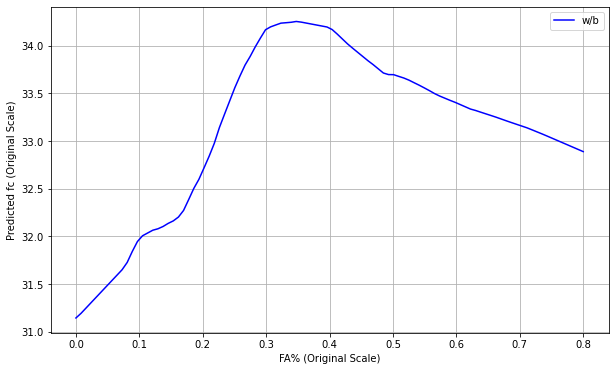

In [55]:
# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
wb_ratio_range = np.linspace(X_normal[:, features.index('SCM%')].min(), X_normal[:, features.index('SCM%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (wb_ratio_range.size, 1)), columns=features)
pdp_data['SCM%'] = wb_ratio_range  # Vary FA%

pdp_data['w/b']=0.4
pdp_data['w/b'] = (pdp_data['w/b']-x_mean[-8])/x_std[-8]
# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
pdp_predictions_normalized = ann_model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['SCM%'] * x_std[features.index('SCM%')] + x_mean[features.index('SCM%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D
# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'SCM%': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_KINN_7_SCM%_0.4.csv', index=False)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='w/b', color='blue')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()